#Fraud Detection



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import ADASYN

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
)
import warnings

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use("ggplot")
np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.float_format', '{:.4f}'.format)
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#загрузка
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/creditcard.csv')

print(df.shape)
display(df.head())


(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0000,94813.8596,47488.1460,0.0000,54201.5000,84692.0000,139320.5000,172792.0000
V1,284807.0000,0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,284807.0000,0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,284807.0000,-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,284807.0000,0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,284807.0000,0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,284807.0000,0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,284807.0000,-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,284807.0000,0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,284807.0000,-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.duplicated().sum()

np.int64(1081)

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

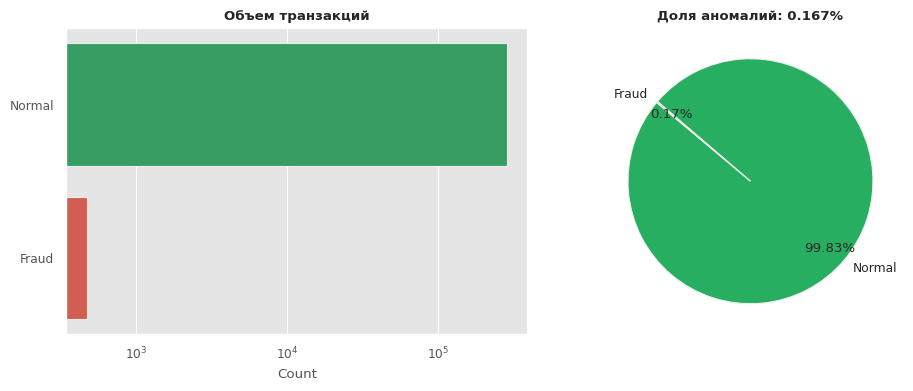

In [ ]:
#проверка баланса
import matplotlib.pyplot as plt
import seaborn as sns

counts = df["Class"].value_counts()
fraud_ratio = (counts[1] / len(df)) * 100


my_colors = ['#27ae60', '#e74c3c']

sns.set_context("paper")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(x=counts.values, y=["Normal", "Fraud"], ax=ax1, palette=my_colors, hue=["Normal", "Fraud"], legend=False)
ax1.set_xscale('log')
ax1.set_title("Объем транзакций", fontweight='bold')
ax1.set_xlabel("Count")

ax2.pie(counts.values, labels=["Normal", "Fraud"], autopct='%1.2f%%',
        startangle=140, pctdistance=0.85, colors=my_colors)
ax2.set_title(f"Доля аномалий: {fraud_ratio:.3f}%", fontweight='bold')

plt.tight_layout()
plt.show()


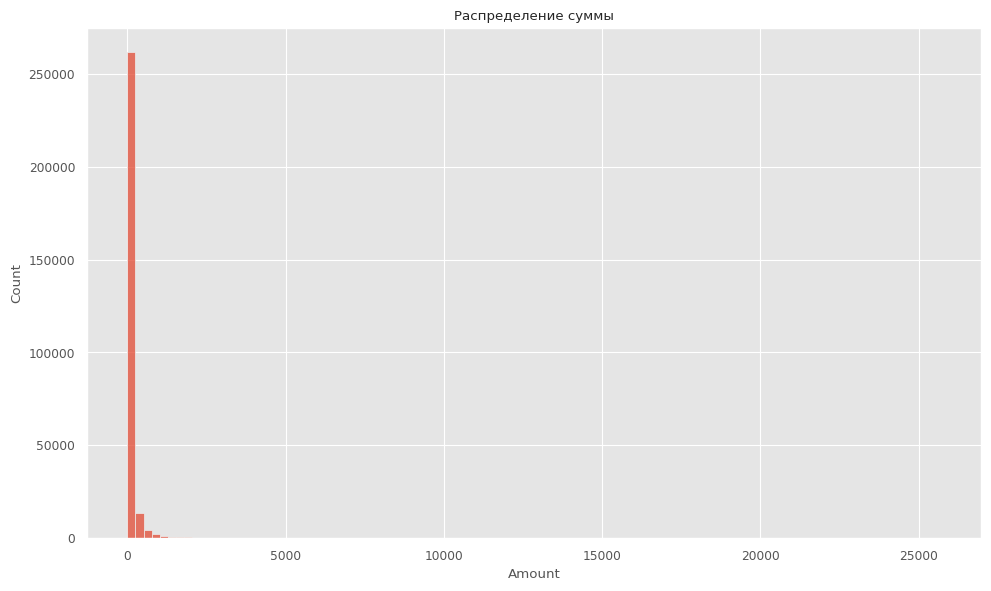

In [ ]:
sns.histplot(df["Amount"], bins=100)
plt.title("Распределение суммы")
plt.tight_layout()
plt.show()

In [ ]:
# сгладим перекосы у суммы для более простого обучения
df['Amount_log'] = np.log1p(df['Amount'])

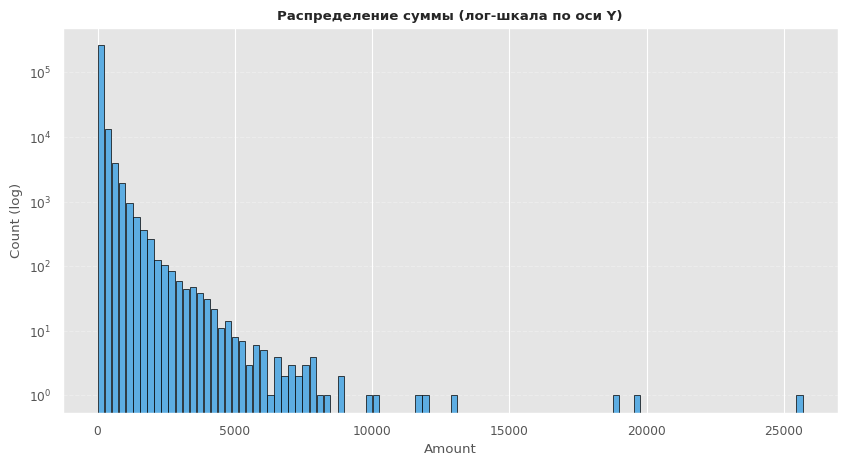

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

counts, bins = np.histogram(df["Amount"], bins=100)
bin_centers = (bins[:-1] + bins[1:]) / 2
width = (bins[1] - bins[0]) * 0.9

plt.figure(figsize=(10, 5))

plt.bar(bin_centers, counts, width=width, color="#5dade2", edgecolor="black", linewidth=0.5)
plt.yscale('log')

plt.title("Распределение суммы (лог-шкала по оси Y)", fontweight='bold')
plt.xlabel("Amount")
plt.ylabel("Count (log)")
plt.grid(axis='y', ls='--', alpha=0.3)

plt.show()

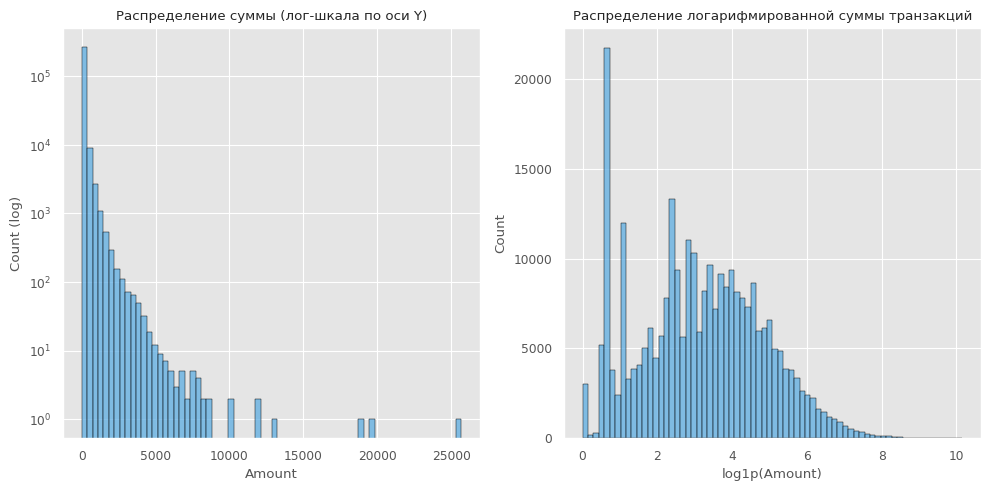

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.histplot(df["Amount"], color="#5dade2", edgecolor="black", bins=70, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Распределение суммы (лог-шкала по оси Y)")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Count (log)")

sns.histplot(df["Amount_log"], color="#5dade2", edgecolor="black", bins=70, ax=axes[1])
axes[1].set_title("Распределение логарифмированной суммы транзакций")
axes[1].set_xlabel("log1p(Amount)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
# извлекаем сутки
df['hour'] = ((df['Time'] // 3600) % 24).astype(int)

# Флаг ночи
df['night'] = df['hour'].isin([22, 23, 0, 1, 2, 3, 4, 5]).astype(int)

# Флаг рабочих часов
df['work_hours'] = df['hour'].between(9, 17).astype(int)

v_features = [c for c in df.columns if c.startswith("V")]
time_features = ['hour', 'night', 'work_hours']
final_features = v_features + ['Amount_log'] + time_features

target = "Class"

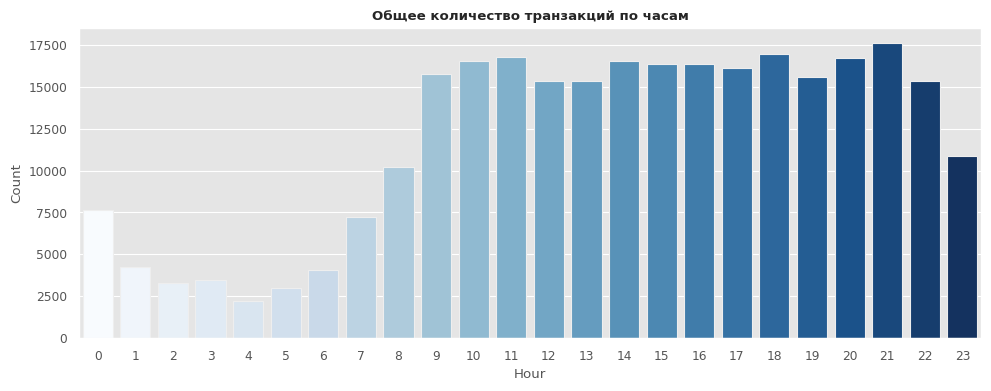

In [ ]:
transactions_by_hour = df.groupby("hour")[target].count()

plt.figure(figsize=(10, 4))
sns.barplot(x=transactions_by_hour.index, y=transactions_by_hour.values, palette='Blues', hue=transactions_by_hour.index, legend=False)
plt.title("Общее количество транзакций по часам", fontweight='bold')
plt.xlabel('Hour')
plt.ylabel("Count")
plt.tight_layout()
plt.show()

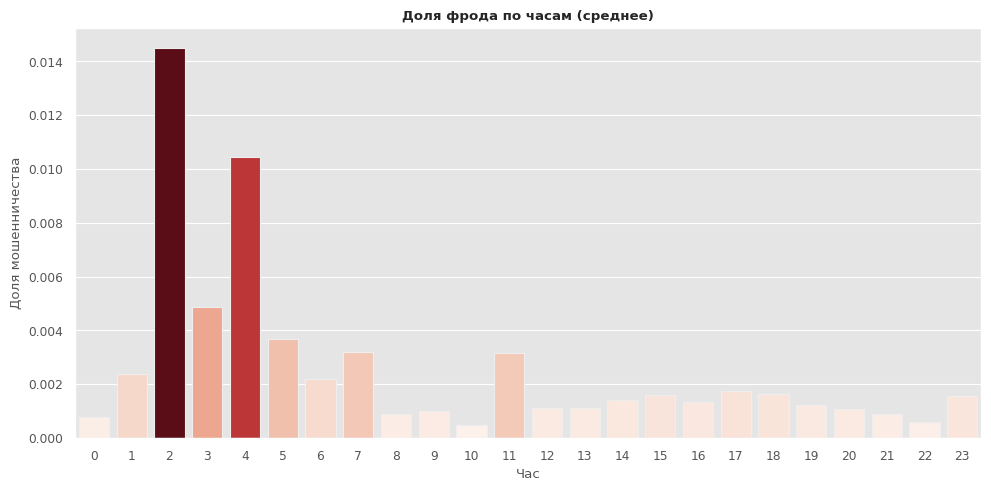

In [ ]:
# Считаем среднюю долю фрода для каждого часа
fraud_by_hour = df.groupby("hour")["Class"].mean()

cmap = sns.color_palette("Reds", as_cmap=True)
# Нормируем
norm_vals = (fraud_by_hour / fraud_by_hour.max()).values
colors = [cmap(v) for v in norm_vals]

plt.figure(figsize=(10, 5))
sns.barplot(x=fraud_by_hour.index, y=fraud_by_hour.values, palette=colors, hue=fraud_by_hour.index, legend=False)

plt.title("Доля фрода по часам (среднее)", fontweight='bold')
plt.xlabel("Час")
plt.ylabel("Доля мошенничества")
plt.tight_layout()
plt.show()

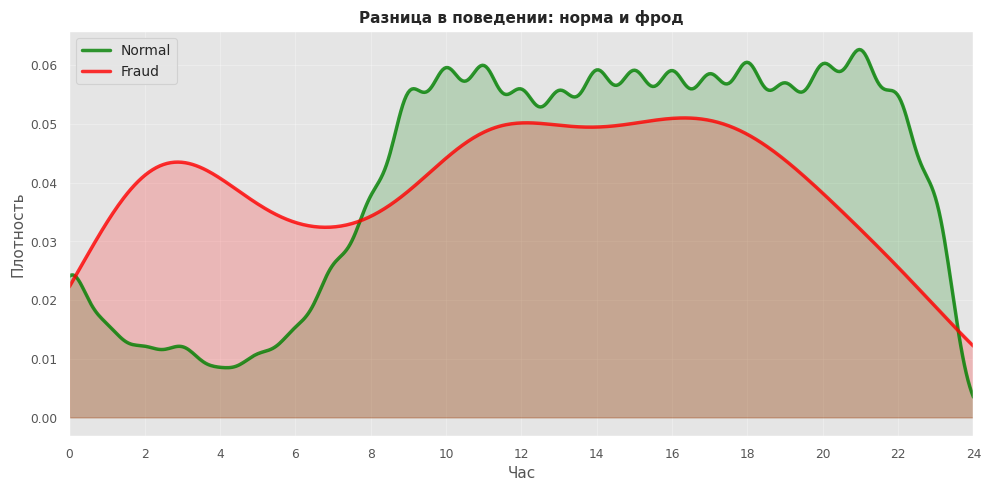

In [ ]:
# kde
from scipy import stats

legit_hours = df[df[target] == 0]['hour']
fraud_hours = df[df[target] == 1]['hour']

legit_kde = stats.gaussian_kde(legit_hours)
fraud_kde = stats.gaussian_kde(fraud_hours)

time_range = np.linspace(0, 24, 500)

plt.figure(figsize=(10, 5))

plt.plot(time_range, legit_kde(time_range), color="green", linewidth=2.5, label="Normal", alpha=0.8)
plt.fill_between(time_range, legit_kde(time_range), alpha=0.2, color="green")

plt.plot(time_range, fraud_kde(time_range), color="red", linewidth=2.5, label="Fraud", alpha=0.8)
plt.fill_between(time_range, fraud_kde(time_range), alpha=0.2, color="red")

plt.xlabel("Час", fontsize=11)
plt.ylabel("Плотность", fontsize=11)
plt.title("Разница в поведении: норма и фрод", fontsize=11, fontweight="bold")
plt.xlim(0, 24)
plt.xticks(range(0, 25, 2))
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

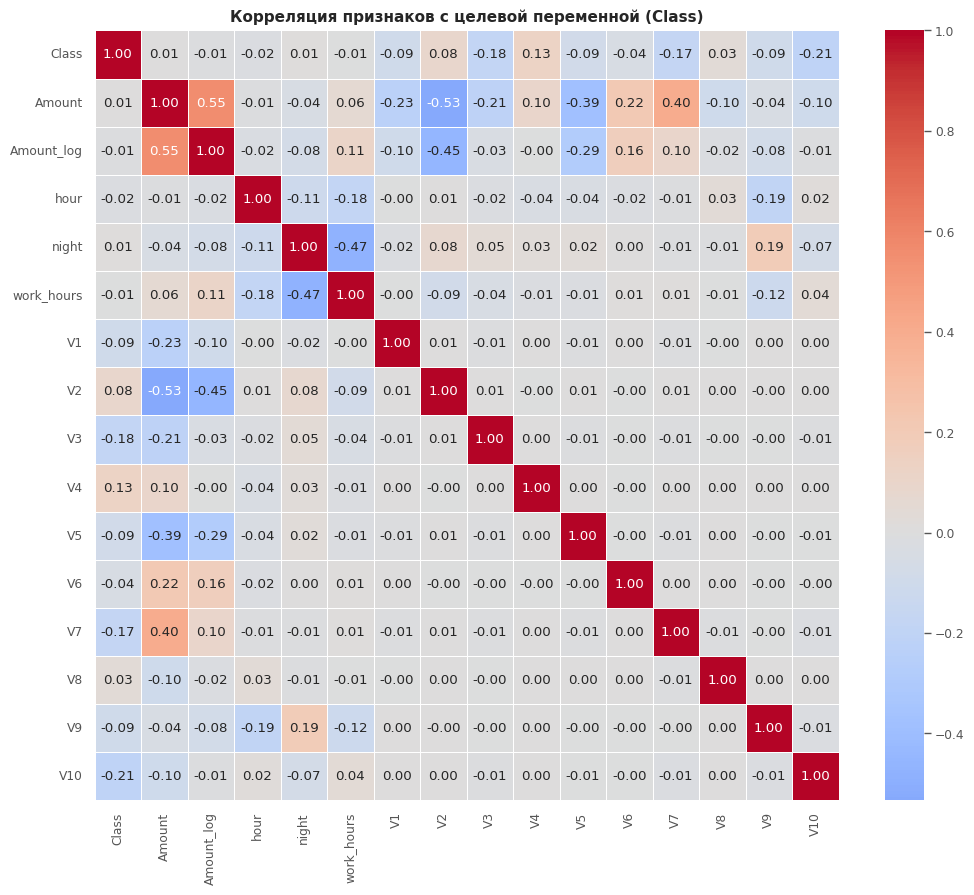

In [ ]:
# матрица корреляции

corr_features = ['Class', 'Amount', 'Amount_log', 'hour', 'night', 'work_hours'] + [f'V{i}' for i in range(1, 11)]

plt.figure(figsize=(12, 10))

corr_matrix = df[corr_features].corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.title("Корреляция признаков с целевой переменной (Class)", fontweight='bold', fontsize=11)
plt.show()

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Amount_log', 'hour', 'night', 'work_hours'],
      dtype='object')

In [ ]:
df.drop(columns = ['Amount'], inplace=True)

In [ ]:
df.drop(columns = ['Time'], inplace=True)

In [ ]:
df.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_log',
       'hour', 'night', 'work_hours'],
      dtype='object')

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train: {len(X_train)}")
print(f"X_test: {len(X_test)}")
print(f"\nTrain class:")
print(y_train.value_counts())
print(f"\nTestclass:")
print(y_test.value_counts())

X_train: 226980
X_test: 56746

Train class:
Class
0    226602
1       378
Name: count, dtype: int64

Testclass:
Class
0    56651
1       95
Name: count, dtype: int64


In [ ]:
#функция с метриками
from sklearn.metrics import precision_recall_fscore_support, fbeta_score
def full_model_analysis(model, X_train, y_train, X_test, y_test, beta=2):

    probs_train = model.predict_proba(X_train)[:, 1]
    probs_test = model.predict_proba(X_test)[:, 1]

    precision_curve, recall_curve, thresholds_curve = precision_recall_curve(y_test, probs_test)

    step = 10
    f_scores = [
        fbeta_score(y_test, (probs_test >= t).astype(int), beta=beta, zero_division=0)
        for t in thresholds_curve[::step]
    ]
    best_t = thresholds_curve[::step][np.argmax(f_scores)]
    ap_score = average_precision_score(y_test, probs_test)

    # сетка порогов
    basic_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    thresholds_to_check = sorted(list(set(basic_grid + [round(best_t, 4)])))

    print(f"\nАнализ порогов (Beta={beta}):")
    print(f"{'Порог':<12} | {'Prec. (Ts)':<10} | {'Rec. (Ts)':<10} | {'F2 (Ts)':<10} | {'Diff (Tr/Ts)':<10}")
    print("-" * 75)

    for t in thresholds_to_check:
        tr_preds = (probs_train >= t).astype(int)
        te_preds = (probs_test >= t).astype(int)

        p_ts = precision_score(y_test, te_preds, zero_division=0)
        r_ts = recall_score(y_test, te_preds, zero_division=0)
        f2_ts = fbeta_score(y_test, te_preds, beta=beta, zero_division=0)
        f2_tr = fbeta_score(y_train, tr_preds, beta=beta, zero_division=0)

        diff = abs(f2_tr - f2_ts)
        print(f"{t:<12.4f} | {p_ts:<10.4f} | {r_ts:<10.4f} | {f2_ts:<10.4f} | {diff:<10.4f}")

    print(f"\nAverage Precision (AP): {ap_score:.4f}")

    # графики PRC и матрица ошибок
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].plot(recall_curve, precision_curve, color='firebrick', lw=2)
    ax[0].set_title(f'PR Curve (AP={ap_score:.4f})')
    ax[0].set_xlabel('Recall')
    ax[0].set_ylabel('Precision')
    ax[0].grid(True, alpha=0.3)

    #матрица ошибок для классического порога 0.5
    cm = confusion_matrix(y_test, (probs_test >= 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', ax=ax[1])
    ax[1].set_title('Confusion Matrix (Threshold 0.5)')
    ax[1].set_ylabel('Real')
    ax[1].set_xlabel('Predicted')
    plt.show()


#full_model_analysis(final_calibrated_pipe, X_train, y_train, X_test, y_test)

Результаты модели:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.77      0.79      0.78        95

    accuracy                           1.00     56746
   macro avg       0.88      0.89      0.89     56746
weighted avg       1.00      1.00      1.00     56746


Анализ порогов (Beta=2):
Порог        | Prec. (Ts) | Rec. (Ts)  | F2 (Ts)    | Diff (Tr/Ts)
---------------------------------------------------------------------------
0.1000       | 0.2760     | 0.8105     | 0.5842     | 0.0267    
0.2000       | 0.5168     | 0.8105     | 0.7278     | 0.0343    
0.3000       | 0.6552     | 0.8000     | 0.7661     | 0.0267    
0.4000       | 0.7143     | 0.7895     | 0.7732     | 0.0279    
0.5000       | 0.7653     | 0.7895     | 0.7845     | 0.0212    
0.5046       | 0.7812     | 0.7895     | 0.7878     | 0.0170    
0.6000       | 0.8132     | 0.7789     | 0.7856     | 0.0253    
0.7000       | 0.8202     | 0.

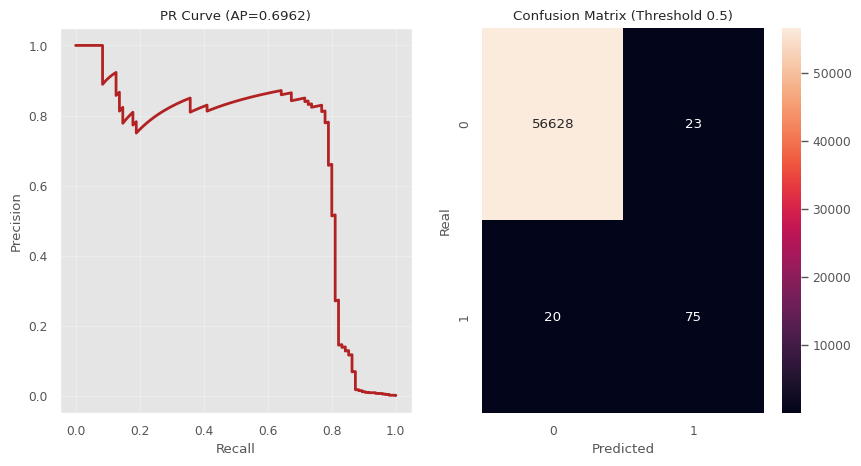

In [ ]:
# Baseline модель LogReg

model_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    #('under', RandomUnderSampler(sampling_strategy=0.2, random_state=42) ),
    #('over', SMOTETomek(tomek=TomekLinks(sampling_strategy='all'), random_state=42)),
    #("smote", SMOTE(k_neighbors=2, random_state=42)),
    #("adasyn",ADASYN() ),
    ('model',  LogisticRegression(random_state=42, max_iter=1000 ,class_weight={0: 1, 1: 15}))#LogisticRegression(max_iter=1000, C=0.0001, random_state=42))#class_weight={0: 1, 1:10}, random_state=42))
])

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

print("Результаты модели:")
print(classification_report(y_test, y_pred))

full_model_analysis(model_pipeline, X_train, y_train, X_test, y_test)

LogReg с откалиброванными вероятностями
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.87      0.62      0.72        95

    accuracy                           1.00     56746
   macro avg       0.93      0.81      0.86     56746
weighted avg       1.00      1.00      1.00     56746


Анализ порогов (Beta=2):
Порог        | Prec. (Ts) | Rec. (Ts)  | F2 (Ts)    | Diff (Tr/Ts)
---------------------------------------------------------------------------
0.0275       | 0.7732     | 0.7895     | 0.7862     | 0.0186    
0.1000       | 0.8235     | 0.7368     | 0.7527     | 0.0257    
0.2000       | 0.8481     | 0.7053     | 0.7298     | 0.0058    
0.3000       | 0.8649     | 0.6737     | 0.7048     | 0.0007    
0.4000       | 0.8696     | 0.6316     | 0.6682     | 0.0090    
0.5000       | 0.8676     | 0.6211     | 0.6585     | 0.0239    
0.6000       | 0.8475     | 0.5263     | 0.5695     | 0.0406    
0.7000   

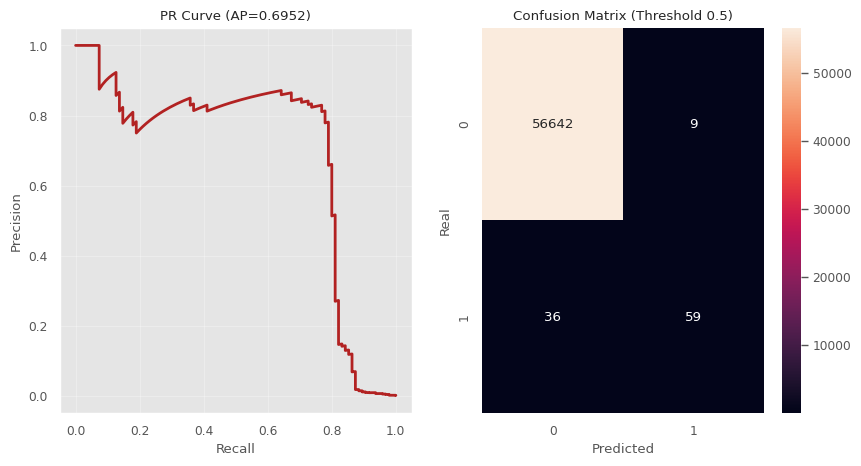

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

base_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight={0: 1, 1: 15}
)

# калибровка,что бы получить несмещенные вероятности
calibrated_model = CalibratedClassifierCV(base_model, cv=5, method='sigmoid')

final_calibrated_pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ('model', calibrated_model)
])

final_calibrated_pipe.fit(X_train, y_train)
y_pred_calibrated = final_calibrated_pipe.predict(X_test)


print("LogReg с откалиброванными вероятностями")
print(classification_report(y_test, y_pred_calibrated))

full_model_analysis(final_calibrated_pipe, X_train, y_train, X_test, y_test)

In [ ]:
from sklearn.metrics import recall_score, precision_score, average_precision_score

print(f"{'Seed':<6} | {'Precision':<10} | {'Recall':<10} | {'AP Score':<10}")
print("-" * 45)

# проверим что модель не штормит на разных семплах
for seed in [1, 42, 100, 777, 999]:

    pipe = final_calibrated_pipe

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_probs = pipe.predict_proba(X_test)[:, 1]

    # 4. Считаем метрики
    p = precision_score(y_test, y_pred)
    r = recall_score(y_test, y_pred)
    ap = average_precision_score(y_test, y_probs)

    print(f"{seed:<6} | {p:<10.4f} | {r:<10.4f} | {ap:<10.4f}")
    print(f"AP Score: {average_precision_score(y_test, y_probs):.4f}")

Seed   | Precision  | Recall     | AP Score  
---------------------------------------------
1      | 0.8676     | 0.6211     | 0.6952    
AP Score: 0.6952
42     | 0.8676     | 0.6211     | 0.6952    
AP Score: 0.6952
100    | 0.8676     | 0.6211     | 0.6952    
AP Score: 0.6952
777    | 0.8676     | 0.6211     | 0.6952    
AP Score: 0.6952
999    | 0.8676     | 0.6211     | 0.6952    
AP Score: 0.6952


In [ ]:
from sklearn.svm import SVC

# linear SVC - проверим другую модель
under = RandomUnderSampler(sampling_strategy=0.2, random_state=42)
svc_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ('under', under),
    ('SMOTE', SMOTE(k_neighbors=2, random_state=42)),
    ('model', SVC(
        kernel='linear',
        #class_weight={0: 1, 1: 10},
        C=0.0001,
        probability=True,
        random_state=42
    ))
])

svc_pipeline.fit(X_train, y_train)

y_pred_svc = svc_pipeline.predict(X_test)

print("Результаты SVC (Linear):")
print(classification_report(y_test, y_pred_svc))

Результаты SVC (Linear):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.78      0.78      0.78        95

    accuracy                           1.00     56746
   macro avg       0.89      0.89      0.89     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
!pip install dask distributed --upgrade

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:43395
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:38591'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:35947'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:44293 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:44293
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:52280
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:38211 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:38211
INFO:distributed.core:Starting established connection to tcp://127

Dask Dashboard: http://127.0.0.1:8787/status
Fold  | Prec.      | Rec. (0.5)   | AP Score  
--------------------------------------------------


INFO:distributed.scheduler:Receive client connection: Client-worker-aaee6dda-0751-11f1-b704-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:53946
INFO:distributed.scheduler:Receive client connection: Client-worker-aaf81ef8-0751-11f1-b703-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:53962


1     | 0.0000     | 0.0000       | 0.5592    

Анализ порогов (Beta=2):
Порог        | Prec. (Ts) | Rec. (Ts)  | F2 (Ts)    | Diff (Tr/Ts)
---------------------------------------------------------------------------
0.0140       | 0.5634     | 0.5634     | 0.5634     | 0.2548    
0.1000       | 0.9259     | 0.3521     | 0.4019     | 0.3699    
0.2000       | 0.9167     | 0.1549     | 0.1858     | 0.4944    
0.3000       | 1.0000     | 0.0986     | 0.1203     | 0.4320    
0.4000       | 0.0000     | 0.0000     | 0.0000     | 0.2937    
0.5000       | 0.0000     | 0.0000     | 0.0000     | 0.2636    
0.6000       | 0.0000     | 0.0000     | 0.0000     | 0.1945    
0.7000       | 0.0000     | 0.0000     | 0.0000     | 0.0000    
0.8000       | 0.0000     | 0.0000     | 0.0000     | 0.0000    
0.9000       | 0.0000     | 0.0000     | 0.0000     | 0.0000    

Average Precision (AP): 0.5592


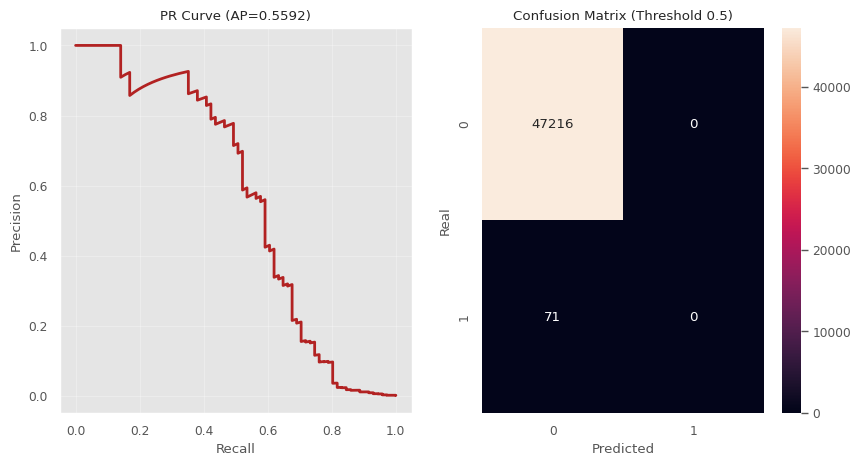

2     | 0.8235     | 0.3043       | 0.6183    

Анализ порогов (Beta=2):
Порог        | Prec. (Ts) | Rec. (Ts)  | F2 (Ts)    | Diff (Tr/Ts)
---------------------------------------------------------------------------
0.0222       | 0.5862     | 0.7391     | 0.7025     | 0.1582    
0.1000       | 0.7667     | 0.5000     | 0.5374     | 0.2666    
0.2000       | 0.7826     | 0.3913     | 0.4348     | 0.3887    
0.3000       | 0.8333     | 0.3261     | 0.3713     | 0.4187    
0.4000       | 0.8235     | 0.3043     | 0.3483     | 0.3816    
0.5000       | 0.8235     | 0.3043     | 0.3483     | 0.3531    
0.6000       | 0.8125     | 0.2826     | 0.3250     | 0.3265    
0.7000       | 0.9091     | 0.2174     | 0.2564     | 0.2615    
0.8000       | 1.0000     | 0.0870     | 0.1064     | 0.2133    
0.9000       | 1.0000     | 0.0652     | 0.0802     | 0.1671    

Average Precision (AP): 0.6183


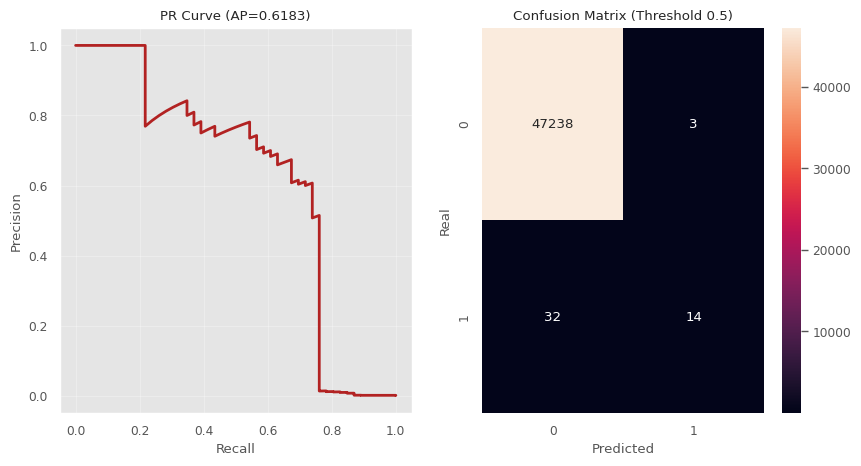

3     | 0.7317     | 0.6742       | 0.7724    

Анализ порогов (Beta=2):
Порог        | Prec. (Ts) | Rec. (Ts)  | F2 (Ts)    | Diff (Tr/Ts)
---------------------------------------------------------------------------
0.1000       | 0.4044     | 0.8315     | 0.6865     | 0.1159    
0.2000       | 0.5902     | 0.8090     | 0.7531     | 0.0592    
0.2442       | 0.6545     | 0.8090     | 0.7725     | 0.0333    
0.3000       | 0.7000     | 0.7865     | 0.7675     | 0.0363    
0.4000       | 0.7356     | 0.7191     | 0.7223     | 0.0337    
0.5000       | 0.7317     | 0.6742     | 0.6849     | 0.0005    
0.6000       | 0.7571     | 0.5955     | 0.6221     | 0.0364    
0.7000       | 1.0000     | 0.4607     | 0.5164     | 0.0557    
0.8000       | 1.0000     | 0.3483     | 0.4005     | 0.1105    
0.9000       | 1.0000     | 0.2809     | 0.3281     | 0.1252    

Average Precision (AP): 0.7724


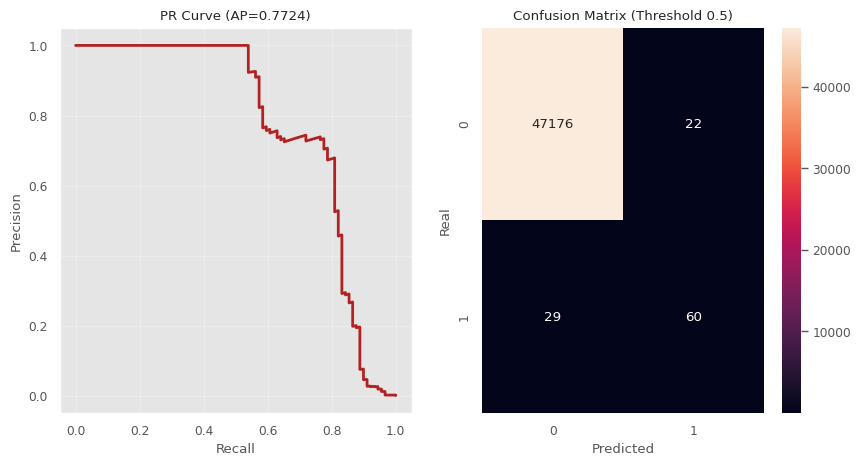

4     | 0.8889     | 0.5333       | 0.7626    

Анализ порогов (Beta=2):
Порог        | Prec. (Ts) | Rec. (Ts)  | F2 (Ts)    | Diff (Tr/Ts)
---------------------------------------------------------------------------
0.0749       | 0.6667     | 0.8000     | 0.7692     | 0.0403    
0.1000       | 0.7385     | 0.8000     | 0.7869     | 0.0039    
0.2000       | 0.7288     | 0.7167     | 0.7191     | 0.0457    
0.3000       | 0.7647     | 0.6500     | 0.6701     | 0.0620    
0.4000       | 0.7778     | 0.5833     | 0.6140     | 0.0725    
0.5000       | 0.8889     | 0.5333     | 0.5797     | 0.0760    
0.6000       | 1.0000     | 0.4667     | 0.5224     | 0.1019    
0.7000       | 1.0000     | 0.2667     | 0.3125     | 0.2238    
0.8000       | 1.0000     | 0.0833     | 0.1020     | 0.3314    
0.9000       | 1.0000     | 0.0167     | 0.0207     | 0.3100    

Average Precision (AP): 0.7626


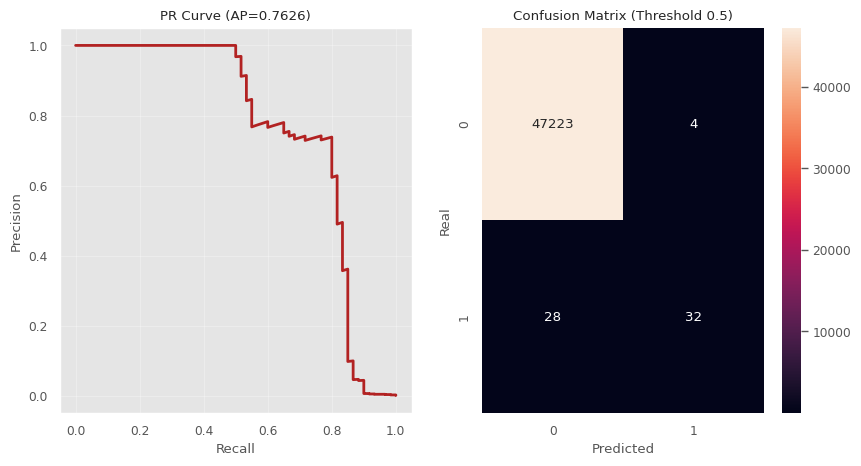

5     | 0.9583     | 0.3770       | 0.7176    

Анализ порогов (Beta=2):
Порог        | Prec. (Ts) | Rec. (Ts)  | F2 (Ts)    | Diff (Tr/Ts)
---------------------------------------------------------------------------
0.0394       | 0.7000     | 0.6885     | 0.6908     | 0.1109    
0.1000       | 0.7600     | 0.6230     | 0.6463     | 0.1338    
0.2000       | 0.7447     | 0.5738     | 0.6014     | 0.1172    
0.3000       | 0.9118     | 0.5082     | 0.5576     | 0.1154    
0.4000       | 0.9643     | 0.4426     | 0.4963     | 0.1413    
0.5000       | 0.9583     | 0.3770     | 0.4291     | 0.1763    
0.6000       | 1.0000     | 0.3607     | 0.4135     | 0.1479    
0.7000       | 1.0000     | 0.3115     | 0.3612     | 0.1105    
0.8000       | 1.0000     | 0.2459     | 0.2896     | 0.1115    
0.9000       | 1.0000     | 0.1311     | 0.1587     | 0.1455    

Average Precision (AP): 0.7176


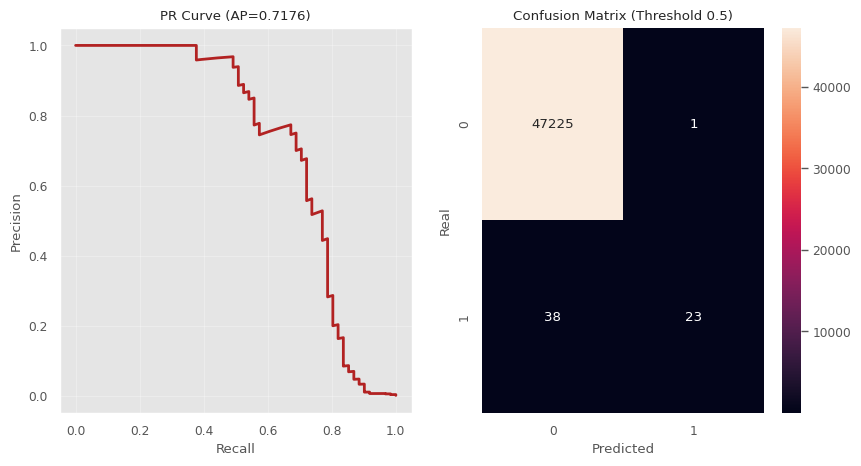


Важность признаков


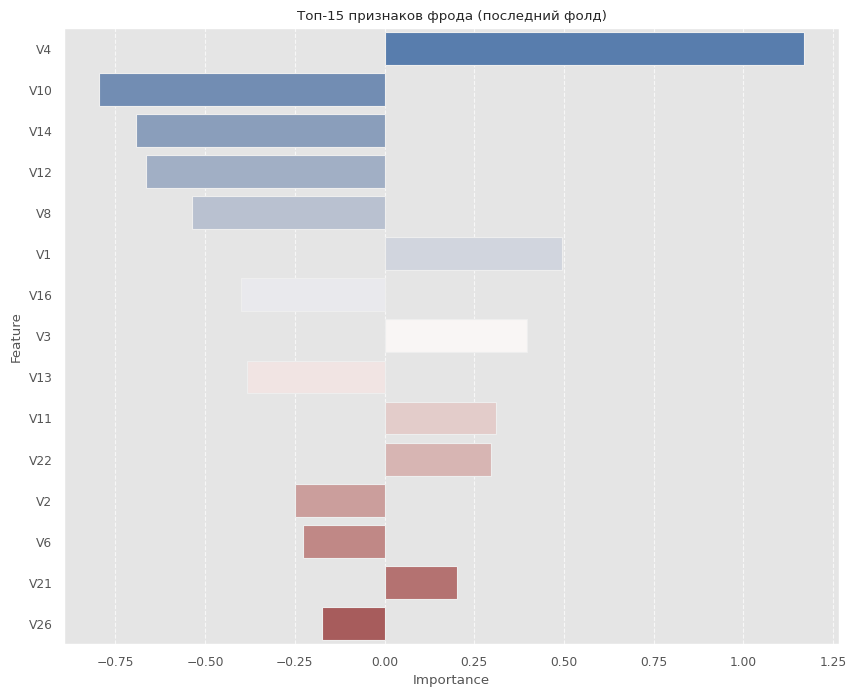

In [ ]:
import joblib
from dask.distributed import Client
from sklearn.model_selection import TimeSeriesSplit
from sklearn.calibration import CalibratedClassifierCV

#Dask
try:
    client = Client()
    print(f"Dask Dashboard: {client.dashboard_link}")
except:
    pass

#базовый пайплайн
base_pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000, class_weight={0: 1, 1: 15}))
])

tscv = TimeSeriesSplit(n_splits=5)

print(f"{'Fold':<5} | {'Prec.':<10} | {'Rec. (0.5)':<12} | {'AP Score':<10}")
print("-" * 50)

fold = 1
for train_idx, test_idx in tscv.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # Калибровка
    calibrated_model = CalibratedClassifierCV(base_pipe, cv=3, method='sigmoid')

    # Обучение через Dask
    with joblib.parallel_backend('dask'):
        calibrated_model.fit(X_tr, y_tr)

    # Метрики для лога
    probs = calibrated_model.predict_proba(X_te)[:, 1]
    preds = calibrated_model.predict(X_te)

    p = precision_score(y_te, preds, zero_division=0)
    r = recall_score(y_te, preds, zero_division=0)
    ap = average_precision_score(y_te, probs)

    print(f"{fold:<5} | {p:<10.4f} | {r:<12.4f} | {ap:<10.4f}")

    full_model_analysis(calibrated_model, X_tr, y_tr, X_te, y_te)

    fold += 1

print("\nВажность признаков")
try:
    calibrator = calibrated_model.calibrated_classifiers_[0]
    internal = getattr(calibrator, 'estimator', getattr(calibrator, 'base_estimator', None))

    if hasattr(internal, 'named_steps'):
        coefs = internal.named_steps['model'].coef_[0]
    else:
        coefs = internal.coef_[0]

    importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': coefs})
    importance_df['Abs'] = importance_df['Importance'].abs()
    importance_df = importance_df.sort_values(by='Abs', ascending=False).head(15)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette='vlag')
    plt.title('Топ-15 признаков фрода (последний фолд)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
except Exception as e:
    print(f"Ошибка:{e}")

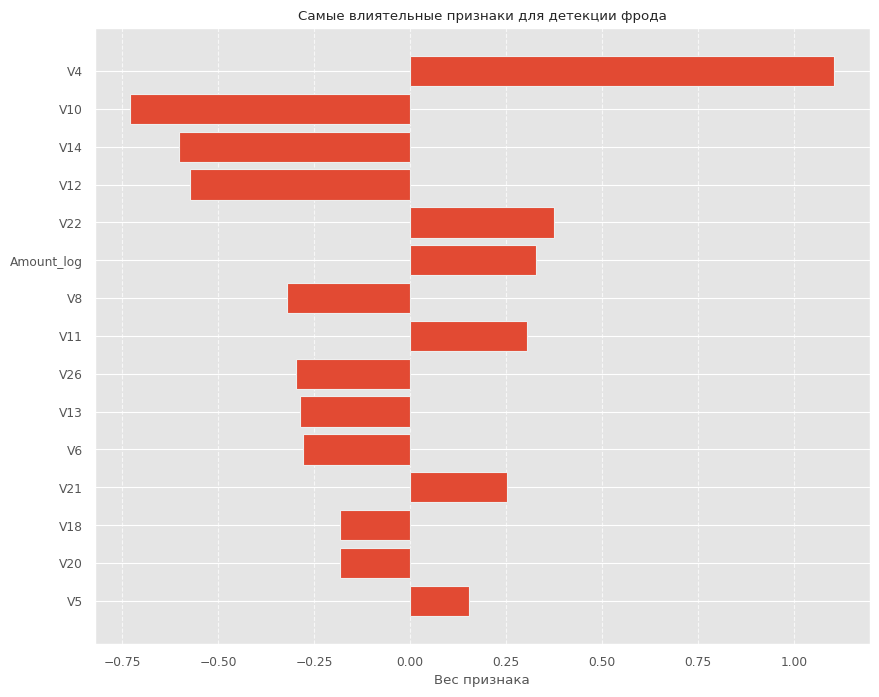

In [ ]:
model_step = final_calibrated_pipe.named_steps['model']

if hasattr(model_step, 'calibrated_classifiers_'):
    calibrator = model_step.calibrated_classifiers_[0]

    internal = getattr(calibrator, 'estimator', getattr(calibrator, 'base_estimator', None))

    if hasattr(internal, 'named_steps'):
        coefs = internal.named_steps['model'].coef_[0]
    else:
        coefs = internal.coef_[0]
else:
    if hasattr(model_step, 'named_steps'):
        coefs = model_step.named_steps['model'].coef_[0]
    else:
        coefs = model_step.coef_[0]

features = X.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': coefs})
importance_df['Abs_Importance'] = importance_df['Importance'].abs()
importance_df = importance_df.sort_values(by='Abs_Importance', ascending=False)

#график важности признаков
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'].head(15), importance_df['Importance'].head(15))
plt.xlabel('Вес признака')
plt.title('Самые влиятельные признаки для детекции фрода')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

 # Выводы

 В данных наблюдается экстремальный дисбаланс (доля фрода < 0.2). Для решения проблемы использовалось взвешивание классов и комбинированные методы сэмплирования (SMOTE + UnderSampling) (на регрессии лучшие результаты дали простые взвешивания классов со стандартизацией).
 Логистическая регрессия показала результаты, сопоставимые с более сложным линейным SVC, при этом работая быстрее и обеспечивая более стабильную калибровку вероятностей. Применение CalibratedClassifierCV позволило перевести абстрактные веса модели в реальные вероятности. Это критически важно для бизнеса, чтобы понимать риск каждой транзакции. Проверка через TimeSeriesSplit  подтвердила устойчивость модели. Итоговый Average Precision составил 0.77.
Стандартная Accuracy не информативна, поэтому  выбрана Average Precision (AP) и F2-score (так как в антифроде пропуск мошенника стоит дороже, чем ложная тревога). Использование калибровки позволило найти рабочий порог 0.1, который обеспечивает максимальную бизнес-эффективность (метрика F2). Переобучения не случилось ни в одном из вариантов (проверяла через гап(мин. =0.0039) трейн-тест F2 метрики). Recall: 80% обнаруживает 8 из 10 мошеннических операций. Precision: 74% всех заблокированных транзакций действительно являются фродом.
